# Ranking pages with weak CTR for their Google position

**Subject: CTR / Engagement Opportunity Scoring**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rimlazrek1/flyrank-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This notebook **resumes** Weeks 3–7: it loads metrics, charts, and the client-holdout action queue from `work/outputs/` (no warehouse pull). Queue previews are capped at **top 10** so the rest of the paper stays readable.

---

## Abstract

Which pages should a reviewer open first when CTR looks weak for their Google position tier? We use ~52k eligible pages from the FlyRank ML Internship warehouse (Mar–Apr 2026 features → May 2026 label; `imp_prev >= 500`). A logistic regression ranked by client-holdout GroupKFold is compared to a transparent past-`ctr_gap` rule. Mean Precision@50 is about 0.945 vs 0.775 (base rate ≈ 0.513), and the top-10 lists barely overlap (0/10). The output is a decision-support review queue — not a promise that edits will raise clicks.

## 1. Question

**Problem.** Many pages earn impressions in Google Search but under-click relative to other pages at a similar average position. Reviewers cannot open every URL; they need a short, ranked list of where CTR looks weak *for the tier*, with a suggested next step.

**Research question.** On a fixed past→future warehouse slice, which pages should a reviewer open first when CTR looks weak for their Google position tier — and does a simple supervised ranker beat a transparent past-`ctr_gap` hand rule at putting May underperformers near the top of that list?

**Decision supported.** A daily (or weekly) **review queue**: open the top-K pages, then choose among rewrite title/meta, check tracking/measurement first, treat as a ranking (not CTR) problem, or monitor. The score orders attention; it does not auto-edit content or promise click lift.

**Why this matters.** Precision@K on the queue is the right product metric: false alarms waste editor time; missed underperformers leave easy wins unread. Client-grouped validation matters because pages from the same site share templates and tracking quirks.

**Claim ladder.** Observed / measured / directional / **decision-support**. We do **not** claim causal proof that an edit raises CTR, access to Google’s ranking algorithm, or that past `ctr_gap` alone is the ground truth for May.

The next cell only loads paper receipts from `work/outputs/` (metrics, queue, figures) so later sections can show numbers without re-pulling the warehouse.

In [1]:
# Setup — load metrics, client-holdout queue, and figures from work/outputs/ (no warehouse pull).
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display, Markdown

candidates = [
    Path("..") / "outputs",          # cwd = work/notebooks
    Path("work") / "outputs",        # cwd = repo root
    Path("outputs"),                 # cwd = work
    Path.cwd() / "work" / "outputs",
]
OUT = next((p.resolve() for p in candidates if p.exists()), None)
if OUT is None:
    raise FileNotFoundError("Could not find work/outputs from " + str(Path.cwd()))
ROOT = OUT.parent
FIG = ROOT / "figures"

QUEUE_COLS = [
    "model_rank", "baseline_rank", "content_hash_id",
    "imp_prev", "ctr_prev", "position_tier",
    "model_score", "baseline_score", "action", "reason_code", "is_ctr_underperformer",
]


def resolve_fig(name: str) -> Path:
    """Prefer w07 exports in outputs/; fall back to figures/."""
    for p in (OUT / name, FIG / name):
        if p.exists():
            return p
    return OUT / name


def show_top10(df: pd.DataFrame, title: str, by: str, cols=None, ascending: bool = True) -> None:
    """Show at most 10 rows so other outputs stay visible."""
    display(Markdown(f"**{title}** (top 10)"))
    cols = cols or [c for c in QUEUE_COLS if c in df.columns]
    view = (df.nsmallest(10, by) if ascending else df.nlargest(10, by))[cols].copy()
    display(view.reset_index(drop=True))


def show_fig(name: str, takeaway: str) -> None:
    path = resolve_fig(name)
    if path.exists():
        display(Image(filename=str(path)))
        print(takeaway)
    else:
        print("Missing figure:", path)


playbook = json.loads((OUT / "playbook_metrics.json").read_text())
model_vs = json.loads((OUT / "model_vs_baseline_metrics.json").read_text())
baseline = json.loads((OUT / "baseline_metrics.json").read_text())
leakage = json.loads((OUT / "validation_leakage_trap.json").read_text())
claims = json.loads((OUT / "validation_claim_rewrite.json").read_text())
methods_mean = pd.DataFrame(model_vs["methods_mean"]).set_index("method")

queue_path = OUT / "action_playbook_queue.csv"
if not queue_path.exists():
    raise FileNotFoundError(
        f"Missing {queue_path} — re-run w07_action_playbook.ipynb to regenerate the queue."
    )
queue = pd.read_csv(queue_path)

print(
    f"Loaded receipts + queue | {playbook['slice']} | "
    f"{len(queue):,} pages | {model_vs['split']} | seed={model_vs['random_state']}"
)

Loaded receipts + queue | features=2026-03+2026-04; label=2026-05 | 52,001 pages | GroupKFold clients n_splits=4 | seed=42


## 2. Data

**Release.** [FlyRank/internship-warehouse](https://huggingface.co/datasets/FlyRank/internship-warehouse) on Hugging Face (gated, instant approval). Build id: `flyrank_pseudonymized_warehouse_release_v20260703`. Source system: FlyRank `central_data_warehouse`, dates roughly **2025-01-27 → 2026-06-30**.

**Tables used.**
| Table | Role here |
|---|---|
| `fact_content_daily_performance` (~78.8M rows; grain `report_date × client × content`, month partitions) | Past features + May label |
| `dim_clients` / `dim_content` (optional joins) | Hash IDs / metadata only — never model features |

We did **not** use `fact_content_query_90d` (fixed 90-day query mix overlaps the label window) or `fact_content_daily_performance_sample` (June 2026 sealed end of panel — not for label development).

**Date windows for this paper.** Features from **`month=2026-03` + `month=2026-04`**. Outcome / label from **`month=2026-05`**. Eligible analysis frame: past ∩ May pages with `imp_prev >= 500` → **52,001** page-rows (~41 clients). Unit of analysis: one page (`content_hash_id`) under one client (`client_hash_id`).

**Warehouse gotchas we respected.** Rate columns are percentage points (`ctr = 0.76` means 0.76%). `gsc_avg_position = 0` means missing, not rank zero. GA4 zeros with `ga4_data_available = FALSE` are not “no engagement.” Client history depth varies — we stay on mid-panel months, not the June sample.

**Excluded (and why).**
- Hash IDs as model features (identity only)
- `trend_direction` / `trend_pct` (other lane; label-adjacent risk)
- Product flags, raw query text, titles, URLs
- GA4 zeros when tracking is unavailable
- Past `ctr_gap` / tier median / May columns as **model** features
- Thin-volume pages (`imp_prev < 500`) from the ranked queue
- Query-90d facts for this snapshot design

**Public-safe.** No client names, private domains, raw URLs, or raw private queries — only scrambled hash IDs and aggregate metrics.

## 3. Methodology

**Assumptions.** Expected CTR differs by position tier. CTR is noisy below ~500 impressions. Same-client pages share site patterns, so validation must group by client. Past features must not include May outcomes.

**Features (5).** `imp_prev`, `ctr_prev`, `pos_avg_prev`, `engagement_rate_prev`, `position_tier` — knowable from Mar–Apr at review time.

**Label.** `is_ctr_underperformer`: May CTR below the median CTR of the page’s May `position_tier`, with enough May impressions. Proxy for “worth a look,” not proof the page is broken.

**Baseline (ML-07).** Rank eligible pages by **past** `ctr_gap` = past tier-median CTR − past page CTR; tie-break `imp_prev`. Transparent hand rule on this out-of-time frame (label is May, so the rule is not perfect by construction).

**Model (ML-08).** Logistic regression (`random_state=42`) ranks by `P(is_ctr_underperformer)`. Past `ctr_gap` is never a model feature. Model queues and model-vs-rule numbers are in Results.

**Validation design.** Client GroupKFold (`n_splits=4`): train clients never appear in that fold’s test. Metric: page-equal Precision@10 / @20 / @50, tie-break `imp_prev`. Queue scores are **client-holdout** (each page scored only when its client was held out; no all-client refit). A random page split is sensitivity-only.

**Leakage checks.** Training with May `ctr_gap_next` drives ROC AUC to 1.0 (trap). Honest five-feature AUC stays lower (~0.76). Forbidden in the model: past `ctr_gap`, May columns, `trend_*`, IDs.

The cell below shows the **baseline queue and baseline metrics** (rule-first view).


In [2]:
show_top10(queue, "Baseline queue (past ctr_gap)", by="baseline_rank")

weak_base = queue.nsmallest(10, "baseline_rank")
weak_base = weak_base[weak_base["is_ctr_underperformer"] == 0]
if len(weak_base):
    show_top10(weak_base, "Baseline top-10 that miss the May label (false alarms)", by="baseline_rank")

display(Markdown("**Baseline metrics (eligible pool, ML-07 receipt)**"))
display(
    pd.DataFrame(
        [
            {"metric": "n pages", "value": baseline["n"]},
            {"metric": "base rate", "value": round(baseline["base_rate"], 3)},
            {"metric": "P@10", "value": baseline["precision_at_10"]},
            {"metric": "P@20", "value": baseline["precision_at_20"]},
            {"metric": "P@50", "value": baseline["precision_at_50"]},
            {"metric": "tie_break", "value": baseline["tie_break"]},
        ]
    )
)

display(Markdown("**Leakage trap (design check)**"))
display(
    pd.DataFrame(
        [
            {"check": "honest AUC (5 features)", "value": round(leakage["auc_honest"], 3)},
            {"check": f"leaky AUC (+{leakage['leaky_feature']})", "value": leakage["auc_leaky"]},
        ]
    )
)


**Baseline queue (past ctr_gap)** (top 10)

,model_rank,baseline_rank,content_hash_id,imp_prev,ctr_prev,position_tier,model_score,baseline_score,action,reason_code,is_ctr_underperformer
0,3231,1,content_cc24743a90439e14,8641.0,0.000000,top_3,0.840803,0.309340,check_tracking_first,zero_click_visible,1
1,3706,2,content_bbcfba786761630c,1685.0,0.000000,top_3,0.834857,0.309340,check_tracking_first,zero_click_visible,1
2,3748,3,content_2012ece8f2deb671,949.0,0.000000,top_3,0.834354,0.309340,check_tracking_first,zero_click_visible,0
3,2148,4,content_1d7764b642f7bb9f,40491.0,0.009879,top_3,0.856003,0.299462,refresh_and_review_ctr,high_visibility_ctr_gap,1
4,5197,5,content_307525daee61f1ba,5526.0,0.018096,top_3,0.816126,0.291244,refresh_and_review_ctr,high_visibility_ctr_gap,1
5,4896,6,content_94ea772ab7347bfe,10108.0,0.019786,top_3,0.819551,0.289554,refresh_and_review_ctr,high_visibility_ctr_gap,1
6,5236,7,content_200d6a6d1cac69b7,4960.0,0.020161,top_3,0.815633,0.289179,refresh_and_review_ctr,high_visibility_ctr_gap,1
7,2886,8,content_6c2da5d67fa888cc,14832.0,0.020227,top_3,0.845328,0.289114,refresh_and_review_ctr,high_visibility_ctr_gap,1
8,5384,9,content_920573540c444f21,4865.0,0.020555,top_3,0.813887,0.288785,refresh_and_review_ctr,high_visibility_ctr_gap,0
9,3142,10,content_eae3c6d98a30d84c,9539.0,0.020967,top_3,0.842068,0.288374,refresh_and_review_ctr,high_visibility_ctr_gap,1


**Baseline top-10 that miss the May label (false alarms)** (top 10)

,model_rank,baseline_rank,content_hash_id,imp_prev,ctr_prev,position_tier,model_score,baseline_score,action,reason_code,is_ctr_underperformer
0,3748,3,content_2012ece8f2deb671,949.0,0.000000,top_3,0.834354,0.309340,check_tracking_first,zero_click_visible,0
1,5384,9,content_920573540c444f21,4865.0,0.020555,top_3,0.813887,0.288785,refresh_and_review_ctr,high_visibility_ctr_gap,0


**Baseline metrics (eligible pool, ML-07 receipt)**

,metric,value
0,n pages,52001
1,base rate,0.515
2,P@10,0.8
3,P@20,0.85
4,P@50,0.78
5,tie_break,imp_prev


**Leakage trap (design check)**

,check,value
0,honest AUC (5 features),0.761
1,leaky AUC (+ctr_gap_next),1.000


## 4. Results (model)

**Model client-holdout queue**, how it differs from the past-`ctr_gap` rule, then GroupKFold Precision@K.

Headline: logistic model mean P@50 ≈ **0.945** vs past-`ctr_gap` ≈ **0.775** (base rate ≈ 0.513). Top-10 model vs baseline overlap is **0/10** — different review orders.

**Model queue (client-holdout score)** (top 10)

,model_rank,baseline_rank,content_hash_id,imp_prev,ctr_prev,position_tier,model_score,baseline_score,action,reason_code,is_ctr_underperformer
0,1,48036,content_eadb33b5df496f4a,1416482.0,0.924968,top_3,0.998201,-0.615627,monitor,general_ctr_monitor,1
1,2,10926,content_77276ad7a26f4905,343846.0,0.141052,page_1,0.977985,0.075031,refresh_and_review_ctr,high_visibility_ctr_gap,1
2,3,17647,content_0e03de7680314cd5,526631.0,0.275715,top_3,0.977086,0.033625,refresh_and_review_ctr,high_visibility_ctr_gap,1
3,4,1027,content_8e1334d6356668e3,263076.0,0.000380,page_1,0.970047,0.215703,refresh_and_review_ctr,high_visibility_ctr_gap,1
4,5,1173,content_9540d884af3e41fd,195020.0,0.014358,page_1,0.968928,0.201725,refresh_and_review_ctr,high_visibility_ctr_gap,1
5,6,5011,content_8d7d99f109e19aa2,395145.0,0.169305,top_3,0.968602,0.140035,refresh_and_review_ctr,high_visibility_ctr_gap,1
6,7,1187,content_44f34c0a90047651,262739.0,0.014844,page_1,0.961691,0.201239,refresh_and_review_ctr,high_visibility_ctr_gap,1
7,8,8724,content_f43118e089ecc69a,315167.0,0.118350,page_1,0.957569,0.097733,refresh_and_review_ctr,high_visibility_ctr_gap,1
8,9,1028,content_fec55986a1868d62,197800.0,0.000506,page_1,0.954354,0.215577,refresh_and_review_ctr,high_visibility_ctr_gap,1
9,10,1088,content_046fc480045b88f5,130115.0,0.009223,page_1,0.953103,0.206860,refresh_and_review_ctr,high_visibility_ctr_gap,1


Top-10 overlap (model vs baseline): 0/10


**Largest rank lift (underperformers: baseline_rank - model_rank)** (top 10)

,model_rank,baseline_rank,rank_lift,content_hash_id,imp_prev,ctr_prev,position_tier,action,is_ctr_underperformer
0,1,48036,48035,content_eadb33b5df496f4a,1416482.0,0.924968,top_3,monitor,1
1,4028,36844,32816,content_f107e54b10b43725,409511.0,0.404629,page_1,monitor,1
2,99,32122,32023,content_963de14b1f58978f,279925.0,0.324015,page_1,monitor,1
3,1384,32551,31167,content_7172a7fad43f0998,385776.0,0.330243,page_1,monitor,1
4,2850,31772,28922,content_00d4fdf6e48a2d38,270334.0,0.319235,page_1,monitor,1
5,8049,35458,27409,content_b556f0bd87d6fcca,248125.0,0.377229,page_1,monitor,1
6,267,26209,25942,content_fd2117c2c6790e4b,270725.0,0.252655,page_1,monitor,1
7,34,25631,25597,content_471d9cabce329a66,335156.0,0.246751,page_1,monitor,1
8,2288,27821,25533,content_519512944d7c341c,229599.0,0.269600,page_1,monitor,1
9,1221,26355,25134,content_df47d1b976106de4,249894.0,0.110447,page_3_5,monitor,1


**GroupKFold mean Precision@K (model vs rule)**

,method,n_folds,n_test_pages_mean,base_rate_mean,precision_at_10,precision_at_20,precision_at_50
0,baseline (ctr_gap),4,13000.25,0.513066,0.85,0.7375,0.775
1,logistic regression,4,13000.25,0.513066,1.00,1.0000,0.945


**Per-fold Precision@50**

method,fold,baseline (ctr_gap),logistic regression
0,1,0.72,0.98
1,2,0.78,0.84
2,3,0.84,0.98
3,4,0.76,0.98


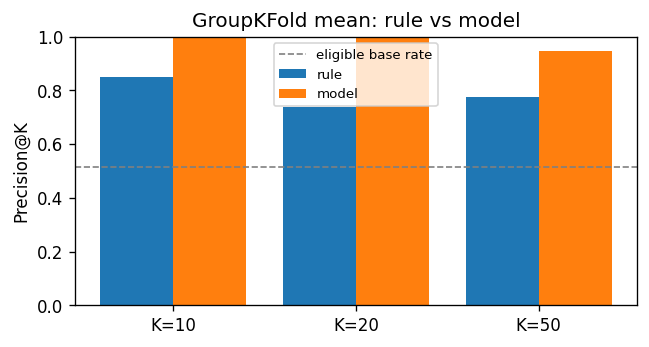

Takeaway: model beats base rate and past-ctr_gap at P@10/20/50.


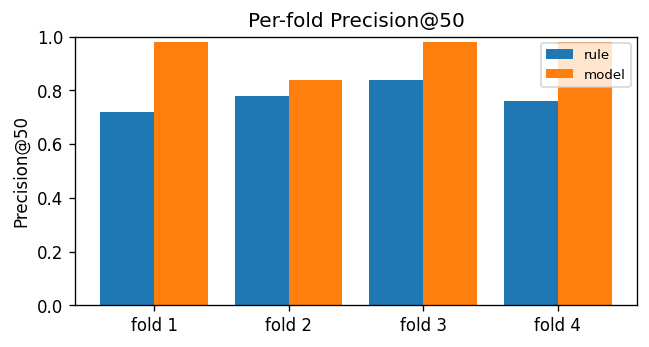

Takeaway: model P@50 stays above the rule in every client fold.


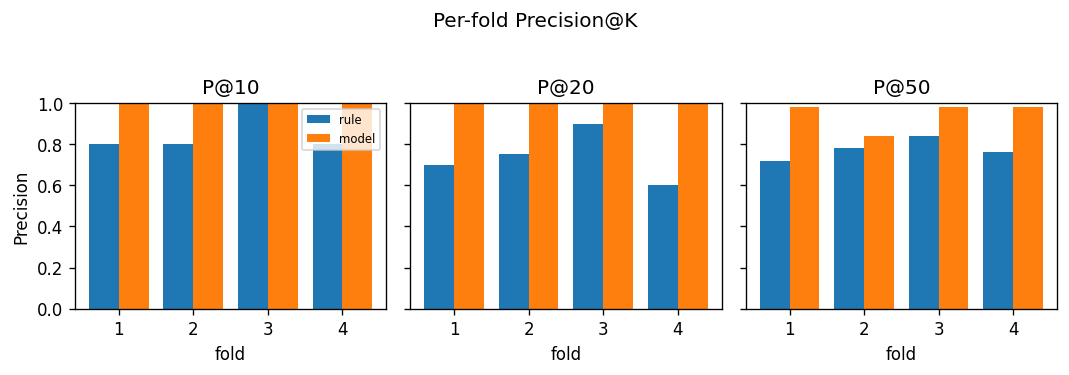

Takeaway: the same ranking lift shows up at P@10, P@20, and P@50.


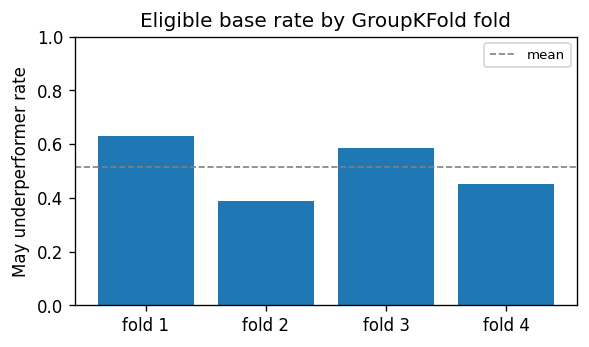

Takeaway: fold base rates differ because GroupKFold holds out different clients.


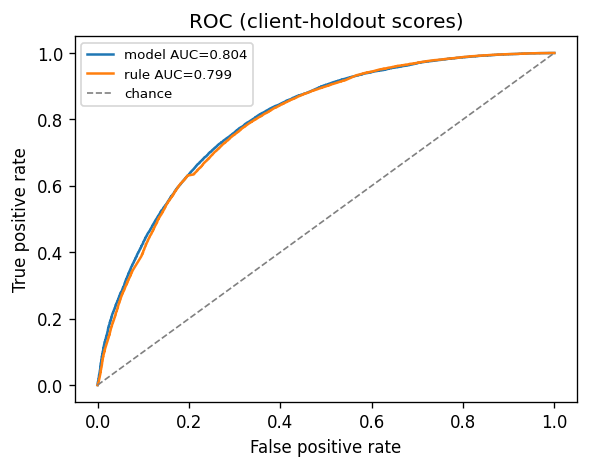

Takeaway: ROC on client-holdout scores is the full ranking, not only the top 10/20/50.


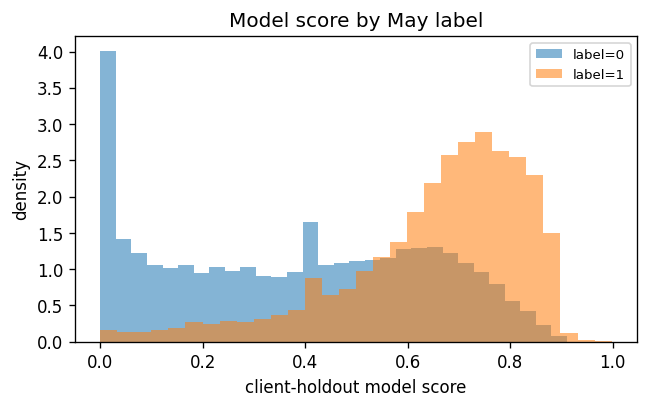

Takeaway: May underperformers tend to get higher client-holdout scores.


**How to read this.** The model wins Precision@K on the same rows and folds. The rule is still the honest hand baseline. Dual ranks show high-stake underperformers the past-ctr_gap rule often places much lower.

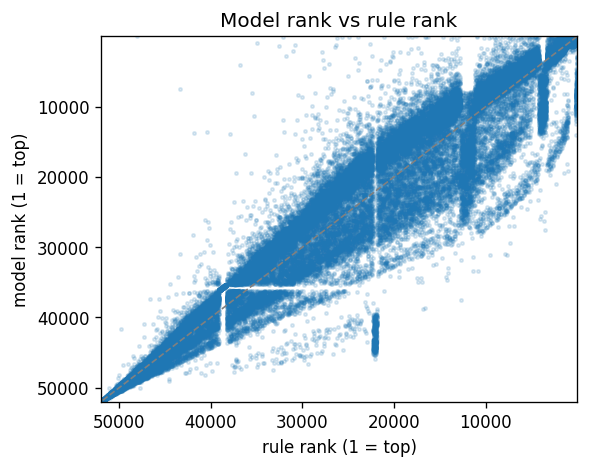

Takeaway: points off the diagonal are pages the two queues would review in a different order.


**Claim wording (validation rewrite)**

BOLD claim: Our model beats the baseline and finds the pages that need a CTR fix.
SAFE claim: On Mar–Apr → May pages (imp_prev >= 500), under client GroupKFold, logistic regression measured mean Precision@K above the base rate and above the past-ctr_gap baseline (see numbers in the cell below). A random page split can look different — we report the grouped number when claiming skill. Week-5 observed the model surfaces high-stake underperformers that the fixed ML-07 ctr_gap rule ranks much lower. This is decision-support ranking, not proof that editing a page will raise clicks.
Sensitivity-only random-split P@50: 0.98 | published GroupKFold P@50: 0.945


In [3]:
# --- Model queue first ---
show_top10(queue, "Model queue (client-holdout score)", by="model_rank")

model_top10 = set(queue.nsmallest(10, "model_rank")["content_hash_id"])
base_top10 = set(queue.nsmallest(10, "baseline_rank")["content_hash_id"])
print(f"Top-10 overlap (model vs baseline): {len(model_top10 & base_top10)}/10")

# Rank-gap: May underperformers the model lifts far above the rule
gap = queue[queue["is_ctr_underperformer"] == 1].copy()
gap["rank_lift"] = gap["baseline_rank"] - gap["model_rank"]
show_top10(
    gap,
    "Largest rank lift (underperformers: baseline_rank - model_rank)",
    by="rank_lift",
    ascending=False,
    cols=[
        "model_rank", "baseline_rank", "rank_lift", "content_hash_id",
        "imp_prev", "ctr_prev", "position_tier", "action", "is_ctr_underperformer",
    ],
)

# --- Model vs baseline metrics ---
display(Markdown("**GroupKFold mean Precision@K (model vs rule)**"))
display(
    methods_mean.reset_index()[
        ["method", "n_folds", "n_test_pages_mean", "base_rate_mean",
         "precision_at_10", "precision_at_20", "precision_at_50"]
    ]
)
display(Markdown("**Per-fold Precision@50**"))
folds = pd.DataFrame(model_vs["fold_rows"])
display(
    folds.pivot_table(
        index="fold", columns="method", values="precision_at_50", aggfunc="first"
    ).reset_index()
)
show_fig(
    "w07_precision_at_k.png",
    "Takeaway: model beats base rate and past-ctr_gap at P@10/20/50.",
)
show_fig(
    "w07_fold_precision_at_50.png",
    "Takeaway: model P@50 stays above the rule in every client fold.",
)
show_fig(
    "w07_fold_precision_at_k.png",
    "Takeaway: the same ranking lift shows up at P@10, P@20, and P@50.",
)
show_fig(
    "w07_fold_base_rate.png",
    "Takeaway: fold base rates differ because GroupKFold holds out different clients.",
)
show_fig(
    "w07_roc.png",
    "Takeaway: ROC on client-holdout scores is the full ranking, not only the top 10/20/50.",
)
show_fig(
    "w07_score_by_label.png",
    "Takeaway: May underperformers tend to get higher client-holdout scores.",
)
display(Markdown(
    "**How to read this.** The model wins Precision@K on the same rows and folds. "
    "The rule is still the honest hand baseline. Dual ranks show high-stake underperformers "
    "the past-ctr_gap rule often places much lower."
))
show_fig(
    "w07_rank_scatter.png",
    "Takeaway: points off the diagonal are pages the two queues would review in a different order.",
)

display(Markdown("**Claim wording (validation rewrite)**"))
print("BOLD claim:", claims["bold_claim"])
print("SAFE claim:", claims["safe_claim"])
print(
    "Sensitivity-only random-split P@50:",
    claims["random_split_for_gap_only"]["precision_at_50"],
    "| published GroupKFold P@50:",
    claims["honest_split"]["precision_at_50"],
)

## 5. Limitations

- Observational only — no causal claim that edits raise clicks.
- May tier-median label is a proxy; zero-click SERPs / tracking gaps look like CTR problems.
- Tier medians are portfolio-specific; GA4 is sparse.
- Queue goes stale when the past window shifts (see decay below).
- Not Google's algorithm.


,top_50_overlap,top_500_overlap,rank_corr
0,0.42,0.23,0.679769


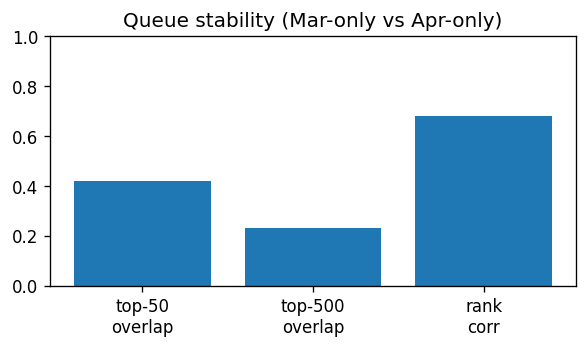

Takeaway: shifting the past window reshuffles the top — treat rankings as perishable.


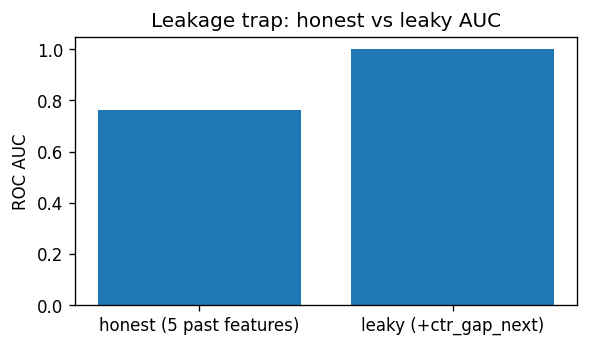

Takeaway: honest past-only AUC ~0.76 vs leaky May ctr_gap_next AUC = 1.0.


In [4]:
display(pd.DataFrame([playbook["decay"]]))
show_fig(
    "w07_queue_stability.png",
    "Takeaway: shifting the past window reshuffles the top — treat rankings as perishable.",
)
show_fig(
    "w07_leakage_auc.png",
    "Takeaway: honest past-only AUC ~0.76 vs leaky May ctr_gap_next AUC = 1.0.",
)

## 6. Ranked recommendations

Ship the **model client-holdout queue** (not the past-`ctr_gap` list). Actions: `refresh_and_review_ctr` / `check_tracking_first` / `ranking_not_ctr` / `monitor`.

Cost sketch (15 min/page, top 50): ~12.5h → ~47 May underperformers vs ~26 at base rate.


**False alarms (high client-holdout score, May label = 0)** (top 10)

,model_rank,baseline_rank,content_hash_id,imp_prev,ctr_prev,position_tier,model_score,baseline_score,action,reason_code,is_ctr_underperformer
0,56,1163,content_a8998878909cee77,28941.0,0.013821,page_1,0.911180,0.202262,refresh_and_review_ctr,high_visibility_ctr_gap,0
1,101,1262,content_83167156f76e33e5,16340.0,0.018360,page_1,0.901490,0.197723,refresh_and_review_ctr,high_visibility_ctr_gap,0
2,122,647,content_2ba481a694613001,1451.0,0.000000,page_1,0.899722,0.216083,check_tracking_first,zero_click_visible,0
3,130,1501,content_87b9188513d77529,26046.0,0.026876,page_1,0.899152,0.189207,refresh_and_review_ctr,high_visibility_ctr_gap,0
4,131,1186,content_6ac93124c81a6993,20288.0,0.014787,page_1,0.899057,0.201296,refresh_and_review_ctr,high_visibility_ctr_gap,0
5,137,416,content_46bf98a63346a13f,2553.0,0.000000,page_1,0.898907,0.216083,check_tracking_first,zero_click_visible,0
6,142,955,content_ac2c42ab8258fc7e,597.0,0.000000,page_1,0.898496,0.216083,check_tracking_first,zero_click_visible,0
7,146,1138,content_321ce8b96df9b82c,7819.0,0.012789,page_1,0.898286,0.203293,refresh_and_review_ctr,high_visibility_ctr_gap,0
8,147,1234,content_0bd6827080aaf5d6,11614.0,0.017221,page_1,0.898268,0.198862,refresh_and_review_ctr,high_visibility_ctr_gap,0
9,152,287,content_5853918576b6d3ce,3855.0,0.000000,page_1,0.898048,0.216083,check_tracking_first,zero_click_visible,0


**Archetype mix (eligible queue)**

,archetype,pages,action,pct_of_all_pages
0,zero_click_visible,1695,check_tracking_first,3.259553
1,high_visibility_ctr_gap,15757,refresh_and_review_ctr,30.301340
2,deep_tier_ctr_gap,4435,ranking_not_ctr,8.528682
3,general_ctr_monitor,30114,monitor,57.910425


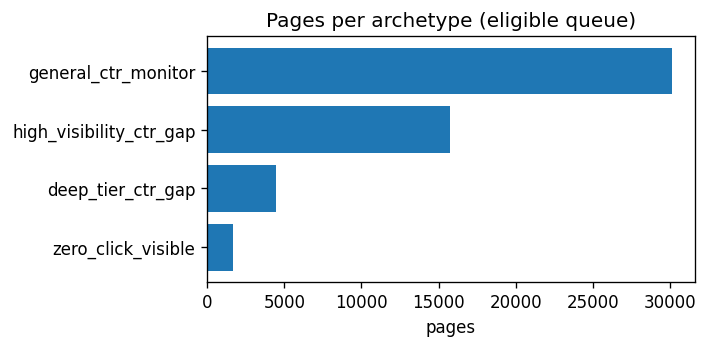

Takeaway: most pages are monitor; focus on high_visibility_ctr_gap + zero_click_visible.
No-go:
 - auto-publish title/meta rewrites
 - prune / merge / redirect without a human
 - act on thin_volume pages (imp_prev < 500)
 - treat deep_tier as a CTR fix
 - promise a click lift to a client
 - use past ctr_gap / May columns / trend_* as model features
 - send the raw queue to a client as an audit


In [5]:
show_top10(
    queue[queue["is_ctr_underperformer"] == 0],
    "False alarms (high client-holdout score, May label = 0)",
    by="model_rank",
)

display(Markdown("**Archetype mix (eligible queue)**"))
display(pd.DataFrame(playbook["archetype_mix"])[["archetype", "pages", "action", "pct_of_all_pages"]])
show_fig(
    "w07_archetype_mix.png",
    "Takeaway: most pages are monitor; focus on high_visibility_ctr_gap + zero_click_visible.",
)

print("No-go:")
for item in playbook["no_go"]:
    print(" -", item)


## 7. Artifacts the paper embeds

| Path | Role |
|---|---|
| `work/outputs/action_playbook_queue.csv` | Full client-holdout queue (gitignored; top-10 shown above) |
| `work/outputs/model_vs_baseline_metrics.json` | GroupKFold Precision@K |
| `work/outputs/playbook_metrics.json` | Archetypes, decay, no-go |
| `work/outputs/baseline_metrics.json` | Eligible-pool baseline |
| `work/outputs/validation_leakage_trap.json` | Honest vs leaky AUC |
| `work/outputs/validation_claim_rewrite.json` | Safe claim wording |
| `work/outputs/w07_precision_at_k.png` | Model vs rule vs base rate |
| `work/outputs/w07_fold_precision_at_50.png` | Per-fold Precision@50 |
| `work/outputs/w07_fold_precision_at_k.png` | Per-fold P@10/20/50 |
| `work/outputs/w07_fold_base_rate.png` | Base rate by fold |
| `work/outputs/w07_roc.png` | ROC (client-holdout scores) |
| `work/outputs/w07_score_by_label.png` | Score by May label |
| `work/outputs/w07_rank_scatter.png` | Model vs rule ranks |
| `work/outputs/w07_queue_stability.png` | Mar-only vs Apr-only decay |
| `work/outputs/w07_leakage_auc.png` | Honest vs leaky ROC AUC |
| `work/outputs/w07_archetype_mix.png` | Action mix |

Upstream: `w03`–`w07`. Regenerate the queue CSV with `w07_action_playbook` if missing.

In [6]:
required_fig_names = [
    "w07_precision_at_k.png",
    "w07_fold_precision_at_50.png",
    "w07_fold_precision_at_k.png",
    "w07_fold_base_rate.png",
    "w07_roc.png",
    "w07_score_by_label.png",
    "w07_rank_scatter.png",
    "w07_queue_stability.png",
    "w07_leakage_auc.png",
    "w07_archetype_mix.png",
]
fig_names = required_fig_names
artifact_paths = [
    OUT / "action_playbook_queue.csv",
    OUT / "model_vs_baseline_metrics.json",
    OUT / "playbook_metrics.json",
    OUT / "baseline_metrics.json",
    OUT / "validation_leakage_trap.json",
    OUT / "validation_claim_rewrite.json",
] + [resolve_fig(n) for n in fig_names]

def _rel(p: Path) -> str:
    try:
        return str(p.relative_to(ROOT.parent if ROOT.name == "work" else ROOT))
    except ValueError:
        return str(p)

status = pd.DataFrame(
    {"path": [_rel(p) for p in artifact_paths], "exists": [p.exists() for p in artifact_paths]}
)
display(status)
assert status["exists"].all(), "Missing paper artifacts — re-run Weeks 5–7 notebooks first."
print("All paper artifacts present.")

,path,exists
0,work\outputs\action_playbook_queue.csv,True
1,work\outputs\model_vs_baseline_metrics.json,True
2,work\outputs\playbook_metrics.json,True
3,work\outputs\baseline_metrics.json,True
4,work\outputs\validation_leakage_trap.json,True
5,work\outputs\validation_claim_rewrite.json,True
6,work\outputs\w07_precision_at_k.png,True
7,work\outputs\w07_fold_precision_at_50.png,True
8,work\outputs\w07_fold_precision_at_k.png,True
9,work\outputs\w07_fold_base_rate.png,True


All paper artifacts present.


## 8. Reproducibility

**Repo.** [rimlazrek1/flyrank-internship](https://github.com/rimlazrek1/flyrank-internship) — notebooks under `work/notebooks/`.

**Upstream notebooks.** `w03_data_contract` → `w04_baseline_score` → `w05_model` → `w06_validation_audit` → `w07_action_playbook` → `capstone`.

**Rerun path.** Install deps from the repo docs; set `HF_TOKEN` in `.env` only if rebuilding warehouse frames. This capstone notebook reads JSON/PNG receipts only (no warehouse pull). Seeds: `random_state=42`. Split: client GroupKFold, `n_splits=4`.

**Public-safe check.** Outputs use hash IDs only — no client names, private URLs, or raw queries. Anyone with the repo can inspect the receipts and re-run the paper notebook.

## 9. Acknowledgments & data credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

Thanks to the FlyRank internship program for the warehouse release, lane framing, and evaluation standards that keep claims public-safe and decision-support honest.

## 10. 5-minute demo outline (Week-8 showcase)

Speak to the paper page + one chart. Keep it under five minutes.

1. **Question (30s).** Which pages should a reviewer open first when CTR looks weak for their Google position tier — a real FlyRank-style content ops decision, not “predict Google’s algorithm.”
2. **Method (90s).** Mar–Apr 2026 features → May 2026 proxy label on ~52k eligible pages (`imp_prev >= 500`). Transparent past-`ctr_gap` rule vs logistic regression. Client GroupKFold (4 folds); queue scores are **client-holdout** (no all-client refit). Same rows, metric, and tie-break (`imp_prev`).
3. **One chart (60s).** Show `w07_precision_at_k.png` (also on the paper page). Point at the grey base-rate line (~0.513), then the rule vs model bars at P@10 / @20 / @50.
4. **One honest result (60s).** Mean Precision@50 ≈ **0.945** (model) vs **0.775** (past-`ctr_gap`) vs ≈ **0.513** base rate. Top-10 lists barely overlap (0/10) — different review order. This is ranking skill on a May proxy label, **not** proof that editing a page raises clicks.
5. **One recommendation (60s).** Ship the **model client-holdout queue**, not the past-`ctr_gap` list. Open high-visibility / tracking-check pages first; leave deep-tier as ranking-not-CTR; never auto-publish rewrites.

**Paper URL:** https://rimlazrek1.github.io/flyrank-internship/  
**Repo:** https://github.com/rimlazrek1/flyrank-internship  


## 11. Shareable cuts

### Cut A — social post (method + finding)

I ranked which Google-visible pages are worth a CTR review first — on ~52k FlyRank internship pages (Mar–Apr → May).

Method: past-`ctr_gap` hand rule vs logistic regression under **client-holdout** GroupKFold (same rows, same Precision@K).

Finding: model mean P@50 ≈ 0.945 vs rule ≈ 0.775 (base rate ≈ 0.51). Decision-support queue, not a click-lift promise.

Chart: Precision@K on the paper → https://rimlazrek1.github.io/flyrank-internship/

---

### Cut B — employer-facing summary (3 sentences)

I built a client-holdout ranked review queue that flags pages whose CTR looks weak for their Google position tier. I trained and validated a logistic model against a transparent past-`ctr_gap` baseline on ~52k eligible pages from the FlyRank ML Internship warehouse (Mar–Apr 2026 features → May 2026 label). Under client GroupKFold, the model’s mean Precision@50 was about 0.945 vs 0.775 for the rule (base rate ≈ 0.51), so reviewers get a clearer top-of-list without claiming that edits will raise clicks.
